# Chronos-2 zero-shot PV forecasting

This notebook evaluates Amazon's pretrained Chronos-2 model using the
same experiment as the TimesFM notebook.

**Initial experiment:** the previous seven days of normalized active
power forecast the next complete day (288 five-minute values). There is
no random noise, GAN, critic, fine-tuning, or model training.

Weather support is included but disabled initially. Set
`USE_WEATHER_COVARIATES = True` to give Chronos-2 past and future weather
without giving it future active power.


## 1. Install and import dependencies

The `amazon/chronos-2` checkpoint has 120 million parameters and is
downloaded from Hugging Face on first use. The official Chronos project
is released under Apache-2.0; review the checkpoint model card before
deployment.


In [1]:
%pip install -q "chronos-forecasting>=2.1.0" pandas scikit-learn matplotlib pvlib


Note: you may need to restart the kernel to use updated packages.


In [2]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pvlib
import torch

from chronos import Chronos2Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch:", torch.__version__)
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


/home/sabos/PV-Digital-Twin-Thesis/notebooks/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.14.0+cu130
Device: cuda
GPU: NVIDIA GeForce RTX 4070


If Hugging Face asks you to authenticate, run the optional login
cell below once. The public checkpoint normally does not require this.


In [3]:
# Optional: uncomment only if Hugging Face asks you to authenticate.
# from huggingface_hub import login
# login()


## 2. PV park metadata and configuration


In [4]:
class PVPark:
    def __init__(
        self,
        name,
        latitude,
        longitude,
        altitude,
        tz,
        tilt,
        azimuth,
        nominal_capacity,
    ):
        self.location = pvlib.location.Location(
            latitude=latitude,
            longitude=longitude,
            altitude=altitude,
            tz=tz,
            name=name,
        )
        self.tilt = tilt
        self.azimuth = azimuth
        self.nominal_capacity = float(nominal_capacity)

    @classmethod
    def from_dataframe(cls, dataframe, index=0):
        row = dataframe.iloc[index]
        latitude = row["latitude"]
        return cls(
            name=row["name"],
            latitude=latitude,
            longitude=row["longitude"],
            altitude=row["altitude"] if pd.notnull(row["altitude"]) else None,
            tz=row["tz"],
            tilt=row["tilt"] if pd.notnull(row["tilt"]) else latitude,
            azimuth=row["azimuth"] if pd.notnull(row["azimuth"]) else 180.0,
            nominal_capacity=row["nominal_capacity"],
        )


In [12]:
base_dir = Path("/home/sabos/PV-Digital-Twin-Thesis/notebooks")
feature_type = "feature-engineered"
weather_source = "station"

TRAIN_PARK_ID = "Gasi-CN448"
TEST_PARK_ID = "Sarafali-CN506"

POINTS_PER_DAY = 288
CONTEXT_DAYS = 7
CONTEXT_LENGTH = CONTEXT_DAYS * POINTS_PER_DAY  # 2016
HORIZON = POINTS_PER_DAY                        # 288
FREQUENCY = "5min"

WEATHER_FEATURES_TO_SCALE = [
    "irradiance",
    "poa_global",
    "dni",
    "dhi",
    "temperature",
]
COVARIATE_FEATURES = [
    "irradiance",
    "poa_global",
    "cos_aoi",
    "dni",
    "dhi",
    "temperature",
    "cos_time",
]

# Start with False for the pure historical-power baseline.
# Change to True later to include past + future weather.
USE_WEATHER_COVARIATES = True

CHRONOS_CHECKPOINT = "amazon/chronos-2"

# Number of independent day-ahead windows sent in each predict_df call.
# Lower this if Colab runs out of GPU memory.
CHRONOS_WINDOWS_PER_CALL = 8

# Same q10-q90 interval as the TimesFM notebook for a fair comparison.
QUANTILE_LEVELS = np.array(
    [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    dtype=float,
)


## 3. Data preparation

Active power is divided by each park's own nominal capacity and clipped
to `[0, 1]`. The weather scaler is fitted on the chronological Park A
training period only and reused for Park A validation and Park B.

A window is accepted only when all context and target days are complete
and consecutive. This prevents a missing date from being silently
treated as the next timestep.


In [13]:
def validate_columns(dataframe, required_columns, dataset_name):
    missing = sorted(set(required_columns) - set(dataframe.columns))
    if missing:
        raise ValueError(f"{dataset_name} is missing columns: {missing}")


def prepare_park_dataframe(
    raw_dataframe,
    park,
    weather_scaler,
):
    required = [
        "collect_time",
        "active_power",
        *COVARIATE_FEATURES,
    ]
    validate_columns(raw_dataframe, required, park.location.name)

    dataframe = raw_dataframe.copy()
    dataframe["collect_time"] = pd.to_datetime(dataframe["collect_time"])
    dataframe = dataframe.sort_values("collect_time").reset_index(drop=True)

    dataframe["active_power_normalized"] = (
        dataframe["active_power"].astype(float) / park.nominal_capacity
    ).clip(lower=0.0, upper=1.0).astype(np.float32)

    dataframe[WEATHER_FEATURES_TO_SCALE] = weather_scaler.transform(
        dataframe[WEATHER_FEATURES_TO_SCALE]
    ).astype(np.float32)

    dataframe["date"] = dataframe["collect_time"].dt.floor("D")
    return dataframe


def build_complete_daily_arrays(dataframe):
    daily_power = []
    daily_covariates = []
    daily_dates = []
    dropped_days = 0

    for date, day in dataframe.groupby("date", sort=True):
        day = day.sort_values("collect_time")
        valid = (
            len(day) == POINTS_PER_DAY
            and not day["collect_time"].duplicated().any()
        )
        if not valid:
            dropped_days += 1
            continue

        daily_power.append(
            day["active_power_normalized"].to_numpy(dtype=np.float32)
        )
        daily_covariates.append(
            day[COVARIATE_FEATURES].to_numpy(dtype=np.float32)
        )
        daily_dates.append(np.datetime64(date, "D"))

    if not daily_power:
        raise ValueError("No complete 288-step days were found.")
    if dropped_days:
        print(f"Dropped {dropped_days} incomplete/duplicated day(s).")

    return (
        np.stack(daily_power),
        np.stack(daily_covariates),
        np.asarray(daily_dates),
    )


def create_day_ahead_windows(
    daily_power,
    daily_covariates,
    daily_dates,
    context_days=7,
    minimum_target_date=None,
):
    contexts = []
    targets = []
    covariates = []
    target_dates = []
    skipped_nonconsecutive = 0

    for target_index in range(context_days, len(daily_dates)):
        start_index = target_index - context_days
        window_dates = daily_dates[start_index : target_index + 1]

        if not np.all(
            np.diff(window_dates).astype("timedelta64[D]")
            == np.timedelta64(1, "D")
        ):
            skipped_nonconsecutive += 1
            continue

        target_date = daily_dates[target_index]
        if minimum_target_date is not None and target_date < minimum_target_date:
            continue

        contexts.append(
            daily_power[start_index:target_index].reshape(-1).astype(np.float32)
        )
        targets.append(daily_power[target_index].astype(np.float32))

        # Internal shape: [features, context + horizon]. It is converted
        # into Chronos-2 context_df and future_df inside the forecast function.
        covariates.append(
            daily_covariates[start_index : target_index + 1]
            .reshape(-1, len(COVARIATE_FEATURES))
            .T
            .astype(np.float32)
        )
        target_dates.append(target_date)

    if not contexts:
        raise ValueError("No valid forecasting windows were created.")
    if skipped_nonconsecutive:
        print(f"Skipped {skipped_nonconsecutive} window(s) crossing missing dates.")

    return contexts, np.stack(targets), covariates, np.asarray(target_dates)


## 4. Load and prepare Park A


In [14]:
train_metadata = pd.read_csv(
    base_dir / "data" / TRAIN_PARK_ID / "metadata.csv"
)
train_park = PVPark.from_dataframe(train_metadata)
train_raw = pd.read_csv(
    base_dir
    / "data"
    / TRAIN_PARK_ID
    / feature_type
    / weather_source
    / "data.csv"
)

train_raw_dates = pd.to_datetime(train_raw["collect_time"]).dt.floor("D")
unique_dates = np.sort(train_raw_dates.unique())
split_index = int(0.70 * len(unique_dates))
validation_start_date = np.datetime64(unique_dates[split_index], "D")
training_rows = train_raw_dates < pd.Timestamp(validation_start_date)

weather_scaler = MinMaxScaler()
weather_scaler.fit(
    train_raw.loc[training_rows, WEATHER_FEATURES_TO_SCALE]
)

train_dataframe = prepare_park_dataframe(
    train_raw,
    train_park,
    weather_scaler,
)
train_daily_power, train_daily_covariates, train_daily_dates = (
    build_complete_daily_arrays(train_dataframe)
)

(
    validation_contexts,
    validation_targets,
    validation_covariates,
    validation_dates,
) = create_day_ahead_windows(
    train_daily_power,
    train_daily_covariates,
    train_daily_dates,
    context_days=CONTEXT_DAYS,
    minimum_target_date=validation_start_date,
)

print(train_park.location)
print("Nominal capacity:", train_park.nominal_capacity)
print("Validation windows:", len(validation_contexts))
print("Context length:", validation_contexts[0].shape)
print("Target shape:", validation_targets.shape)
print("Covariate shape:", validation_covariates[0].shape)


Location: 
  name: Gasi-CN448
  latitude: 35.13
  longitude: 25.259
  altitude: 334.0
  tz: Europe/Athens
Nominal capacity: 405.0
Validation windows: 162
Context length: (2016,)
Target shape: (162, 288)
Covariate shape: (7, 2304)


## 5. Load Chronos-2

This is zero-shot inference: the pretrained 120M-parameter model is
loaded but not fitted on Park A. The first checkpoint download can take
several minutes. Chronos-2 supports up to 8192 context points and 1024
forecast points, so this notebook's 2016-point context and 288-point
horizon are within the documented limits.


In [15]:
chronos_model = Chronos2Pipeline.from_pretrained(
    CHRONOS_CHECKPOINT,
    device_map=device,
)

print("Loaded:", CHRONOS_CHECKPOINT)
print("Weather covariates enabled:", USE_WEATHER_COVARIATES)


Loading weights: 100%|██████████| 170/170 [00:00<00:00, 2071.54it/s]

Loaded: amazon/chronos-2
Weather covariates enabled: True


## 6. Forecasting function

`USE_WEATHER_COVARIATES=False` supplies only historical active power.
When it is `True`, `context_df` contains historical power and historical
weather, while `future_df` contains only forecast-day timestamps and
weather. It never contains forecast-day active power.

Future measured weather is an **oracle experiment**. For operational
forecasting, replace it with weather forecasts available before the
target day.


In [16]:
def make_chronos_batch_frames(
    contexts,
    covariates,
    target_dates,
    global_start_index,
    use_weather_covariates,
):
    context_frames = []
    future_frames = []
    series_ids = []

    for local_index, (context, covariate, target_date) in enumerate(
        zip(contexts, covariates, target_dates)
    ):
        series_id = f"window_{global_start_index + local_index:06d}"
        series_ids.append(series_id)

        target_start = pd.Timestamp(target_date)
        context_start = target_start - pd.Timedelta(days=CONTEXT_DAYS)
        context_timestamps = pd.date_range(
            start=context_start,
            periods=CONTEXT_LENGTH,
            freq=FREQUENCY,
        )

        context_data = {
            "id": series_id,
            "timestamp": context_timestamps,
            "target": np.asarray(context, dtype=np.float32),
        }

        if use_weather_covariates:
            for feature_index, feature_name in enumerate(COVARIATE_FEATURES):
                context_data[feature_name] = covariate[
                    feature_index, :CONTEXT_LENGTH
                ]

            future_data = {
                "id": series_id,
                "timestamp": pd.date_range(
                    start=target_start,
                    periods=HORIZON,
                    freq=FREQUENCY,
                ),
            }
            for feature_index, feature_name in enumerate(COVARIATE_FEATURES):
                future_data[feature_name] = covariate[
                    feature_index, CONTEXT_LENGTH:
                ]
            future_frames.append(pd.DataFrame(future_data))

        context_frames.append(pd.DataFrame(context_data))

    context_df = pd.concat(context_frames, ignore_index=True)
    future_df = (
        pd.concat(future_frames, ignore_index=True)
        if use_weather_covariates
        else None
    )
    return context_df, future_df, series_ids


def get_quantile_column(prediction_dataframe, quantile_level):
    string_name = f"{float(quantile_level):g}"
    if string_name in prediction_dataframe.columns:
        return string_name
    if float(quantile_level) in prediction_dataframe.columns:
        return float(quantile_level)
    raise KeyError(
        f"Chronos output has no q{string_name} column. "
        f"Available columns: {prediction_dataframe.columns.tolist()}"
    )


def run_chronos_forecast(
    model,
    contexts,
    covariates,
    target_dates,
    use_weather_covariates=False,
    windows_per_call=8,
):
    point_forecasts = []
    quantile_forecasts = []

    for start in range(0, len(contexts), windows_per_call):
        stop = min(start + windows_per_call, len(contexts))
        context_df, future_df, series_ids = make_chronos_batch_frames(
            contexts=contexts[start:stop],
            covariates=covariates[start:stop],
            target_dates=target_dates[start:stop],
            global_start_index=start,
            use_weather_covariates=use_weather_covariates,
        )

        predict_arguments = {
            "prediction_length": HORIZON,
            "quantile_levels": QUANTILE_LEVELS.tolist(),
            "id_column": "id",
            "timestamp_column": "timestamp",
            "target": "target",
        }
        if use_weather_covariates:
            predict_arguments["future_df"] = future_df

        prediction_df = model.predict_df(context_df, **predict_arguments)
        quantile_columns = [
            get_quantile_column(prediction_df, level)
            for level in QUANTILE_LEVELS
        ]

        for series_id in series_ids:
            series_prediction = (
                prediction_df.loc[prediction_df["id"] == series_id]
                .sort_values("timestamp")
                .reset_index(drop=True)
            )
            if len(series_prediction) != HORIZON:
                raise ValueError(
                    f"Expected {HORIZON} predictions for {series_id}, "
                    f"received {len(series_prediction)}."
                )

            point_forecasts.append(
                series_prediction["predictions"].to_numpy(dtype=np.float32)
            )
            quantile_forecasts.append(
                series_prediction[quantile_columns].to_numpy(dtype=np.float32)
            )

        print(f"Forecasted {stop}/{len(contexts)} windows")

    point_forecasts = np.clip(np.stack(point_forecasts), 0.0, 1.0)
    quantile_forecasts = np.clip(np.stack(quantile_forecasts), 0.0, 1.0)
    return point_forecasts, quantile_forecasts


In [19]:
import os

os.environ["CC"] = "/usr/bin/gcc"
os.environ["CXX"] = "/usr/bin/g++"

import shutil

print("C compiler:", shutil.which("gcc"))
print("C++ compiler:", shutil.which("g++"))

C compiler: /usr/bin/gcc
C++ compiler: /usr/bin/g++


In [20]:
validation_forecast, validation_quantiles = run_chronos_forecast(
    model=chronos_model,
    contexts=validation_contexts,
    covariates=validation_covariates,
    target_dates=validation_dates,
    use_weather_covariates=USE_WEATHER_COVARIATES,
    windows_per_call=CHRONOS_WINDOWS_PER_CALL,
)

print("Point forecast:", validation_forecast.shape)
print("Quantiles:", validation_quantiles.shape)


Forecasted 8/162 windows
Forecasted 16/162 windows
Forecasted 24/162 windows
Forecasted 32/162 windows
Forecasted 40/162 windows
Forecasted 48/162 windows
Forecasted 56/162 windows
Forecasted 64/162 windows
Forecasted 72/162 windows
Forecasted 80/162 windows
Forecasted 88/162 windows
Forecasted 96/162 windows
Forecasted 104/162 windows
Forecasted 112/162 windows
Forecasted 120/162 windows
Forecasted 128/162 windows
Forecasted 136/162 windows
Forecasted 144/162 windows
Forecasted 152/162 windows
Forecasted 160/162 windows
Forecasted 162/162 windows
Point forecast: (162, 288)
Quantiles: (162, 288, 9)


## 7. Forecast metrics

Chronos-2 returns a point forecast and the quantiles requested above,
without manually injecting random noise. We request q10 through q90 so
the evaluation uses the same central 80% interval as the TimesFM
notebook.


In [21]:
def calculate_forecast_metrics(
    targets,
    point_forecasts,
    quantile_forecasts,
    nominal_capacity,
):
    targets = np.asarray(targets)
    point_forecasts = np.asarray(point_forecasts)
    quantile_forecasts = np.asarray(quantile_forecasts)

    target_flat = targets.reshape(-1)
    forecast_flat = point_forecasts.reshape(-1)
    normalized_mae = mean_absolute_error(target_flat, forecast_flat)
    normalized_rmse = np.sqrt(mean_squared_error(target_flat, forecast_flat))

    lower_80 = quantile_forecasts[:, :, 0]
    upper_80 = quantile_forecasts[:, :, -1]
    inside_80 = (targets >= lower_80) & (targets <= upper_80)

    # Average quantile (pinball) loss; lower is better.
    pinball_losses = []
    for quantile_index, quantile_level in enumerate(QUANTILE_LEVELS):
        error = targets - quantile_forecasts[:, :, quantile_index]
        pinball_losses.append(
            np.maximum(
                quantile_level * error,
                (quantile_level - 1.0) * error,
            ).mean()
        )

    target_energy = targets.sum(axis=1) / 12.0
    forecast_energy = point_forecasts.sum(axis=1) / 12.0
    normalized_energy_mae = np.abs(
        target_energy - forecast_energy
    ).mean()

    return pd.Series(
        {
            "MAE (normalized)": normalized_mae,
            "RMSE (normalized)": normalized_rmse,
            "R²": r2_score(target_flat, forecast_flat),
            "MAE (physical power)": normalized_mae * nominal_capacity,
            "RMSE (physical power)": normalized_rmse * nominal_capacity,
            "Mean quantile loss": np.mean(pinball_losses),
            "80% point coverage": inside_80.mean(),
            "80% interval width": (upper_80 - lower_80).mean(),
            "Daily energy MAE (normalized hours)": normalized_energy_mae,
            "Daily energy MAE (physical)": normalized_energy_mae * nominal_capacity,
            "Ramp MAE": np.abs(
                np.diff(targets, axis=1)
                - np.diff(point_forecasts, axis=1)
            ).mean(),
        }
    )


experiment_label = (
    "Chronos-2 + weather"
    if USE_WEATHER_COVARIATES
    else "Chronos-2 baseline"
)
validation_metrics = calculate_forecast_metrics(
    validation_targets,
    validation_forecast,
    validation_quantiles,
    nominal_capacity=train_park.nominal_capacity,
)
display(validation_metrics.to_frame(f"Park A — {experiment_label}"))


,Park A — Chronos-2 + weather
MAE (normalized),0.011504
RMSE (normalized),0.032931
R²,0.986644
MAE (physical power),4.659220
RMSE (physical power),13.337096
Mean quantile loss,0.004625
80% point coverage,0.884066
80% interval width,0.027490
Daily energy MAE (normalized hours),0.104432
Daily energy MAE (physical),42.294952


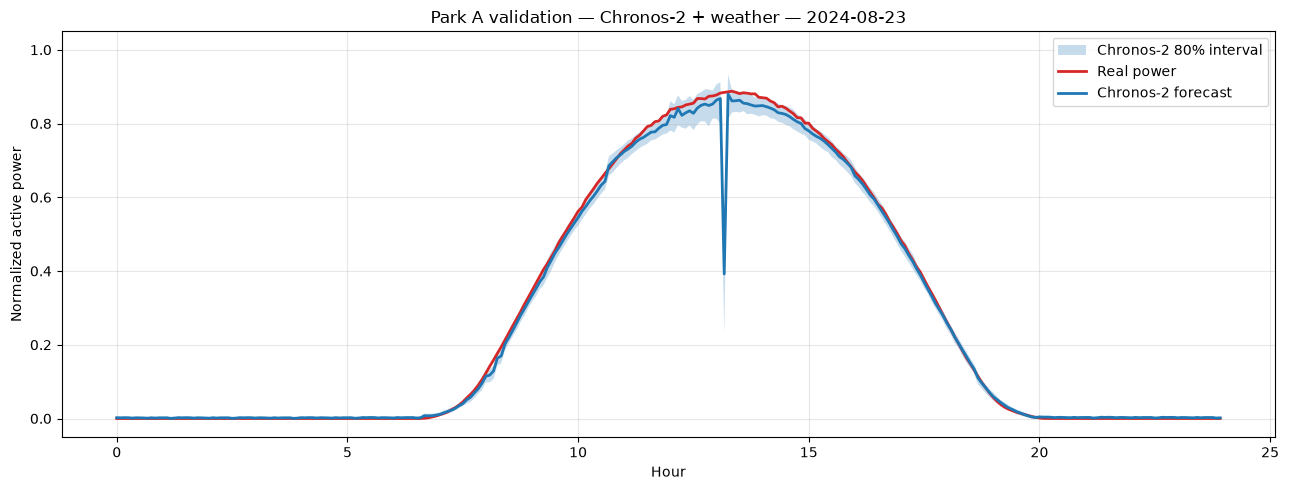

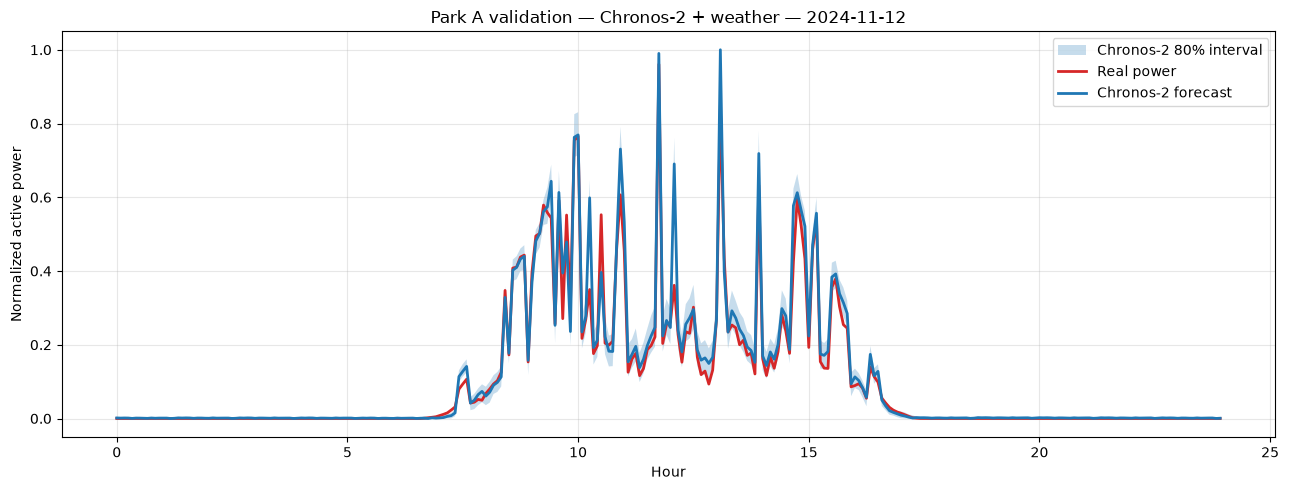

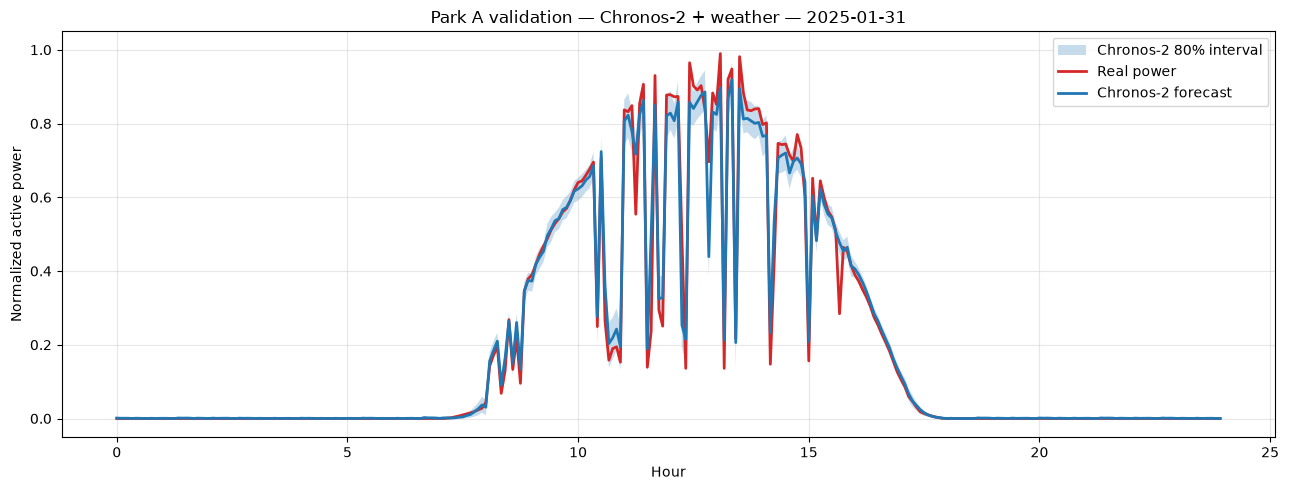

In [22]:
def plot_forecast_day(
    day_index,
    dates,
    targets,
    point_forecasts,
    quantile_forecasts,
    title,
):
    if not 0 <= day_index < len(targets):
        raise IndexError(f"day_index must be between 0 and {len(targets) - 1}.")

    hours = np.arange(HORIZON) / 12.0
    lower_80 = quantile_forecasts[day_index, :, 0]
    upper_80 = quantile_forecasts[day_index, :, -1]

    plt.figure(figsize=(13, 5))
    plt.fill_between(
        hours,
        lower_80,
        upper_80,
        alpha=0.25,
        label="Chronos-2 80% interval",
    )
    plt.plot(
        hours,
        targets[day_index],
        color="tab:red",
        linewidth=2,
        label="Real power",
    )
    plt.plot(
        hours,
        point_forecasts[day_index],
        color="tab:blue",
        linewidth=2,
        label="Chronos-2 forecast",
    )
    plt.title(f"{title} — {dates[day_index]}")
    plt.xlabel("Hour")
    plt.ylabel("Normalized active power")
    plt.ylim(-0.05, 1.05)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


for day_index in sorted(
    set([0, len(validation_targets) // 2, len(validation_targets) - 1])
):
    plot_forecast_day(
        day_index,
        validation_dates,
        validation_targets,
        validation_forecast,
        validation_quantiles,
        title=f"Park A validation — {experiment_label}",
    )


# 8. Test on Park B

Chronos-2 forecasts Park B using Park B's own seven-day active-power
history. Park A contributes only the weather scaler when covariates are
enabled. No Park B active-power values from the forecast day enter the
model.


In [27]:
park_b_metadata = pd.read_csv(
    base_dir / "data" / TEST_PARK_ID / "metadata.csv"
)
park_b = PVPark.from_dataframe(park_b_metadata)

park_b_candidates = [
    # base_dir / "data" / TEST_PARK_ID / feature_type / weather_source / "curtailed" / "data.csv",
    base_dir / "data" / TEST_PARK_ID / feature_type / weather_source / "data.csv",
]
park_b_data_path = next(
    (path for path in park_b_candidates if path.exists()),
    None,
)
if park_b_data_path is None:
    attempted = "\n".join(str(path) for path in park_b_candidates)
    raise FileNotFoundError("Park B data was not found. Checked:\n" + attempted)

park_b_raw = pd.read_csv(park_b_data_path)
park_b_dataframe = prepare_park_dataframe(
    park_b_raw,
    park_b,
    weather_scaler,  # Park A scaler; never refit on Park B
)
park_b_daily_power, park_b_daily_covariates, park_b_daily_dates = (
    build_complete_daily_arrays(park_b_dataframe)
)
(
    park_b_contexts,
    park_b_targets,
    park_b_covariates,
    park_b_dates,
) = create_day_ahead_windows(
    park_b_daily_power,
    park_b_daily_covariates,
    park_b_daily_dates,
    context_days=CONTEXT_DAYS,
)

print(park_b.location)
print("Nominal capacity:", park_b.nominal_capacity)
print("Data path:", park_b_data_path)
print("Park B windows:", len(park_b_contexts))


Location: 
  name: Sarafali-CN506
  latitude: 35.13
  longitude: 25.259
  altitude: 334.0
  tz: Europe/Athens
Nominal capacity: 1000.0
Data path: /home/sabos/PV-Digital-Twin-Thesis/notebooks/data/Sarafali-CN506/feature-engineered/station/data.csv
Park B windows: 175


In [28]:
park_b_forecast, park_b_quantiles = run_chronos_forecast(
    model=chronos_model,
    contexts=park_b_contexts,
    covariates=park_b_covariates,
    target_dates=park_b_dates,
    use_weather_covariates=USE_WEATHER_COVARIATES,
    windows_per_call=CHRONOS_WINDOWS_PER_CALL,
)

park_b_metrics = calculate_forecast_metrics(
    park_b_targets,
    park_b_forecast,
    park_b_quantiles,
    nominal_capacity=park_b.nominal_capacity,
)
display(park_b_metrics.to_frame(f"Park B — {experiment_label}"))


Forecasted 8/175 windows
Forecasted 16/175 windows
Forecasted 24/175 windows
Forecasted 32/175 windows
Forecasted 40/175 windows
Forecasted 48/175 windows
Forecasted 56/175 windows
Forecasted 64/175 windows
Forecasted 72/175 windows
Forecasted 80/175 windows
Forecasted 88/175 windows
Forecasted 96/175 windows
Forecasted 104/175 windows
Forecasted 112/175 windows
Forecasted 120/175 windows
Forecasted 128/175 windows
Forecasted 136/175 windows
Forecasted 144/175 windows
Forecasted 152/175 windows
Forecasted 160/175 windows
Forecasted 168/175 windows
Forecasted 175/175 windows


,Park B — Chronos-2 + weather
MAE (normalized),0.012758
RMSE (normalized),0.040823
R²,0.975975
MAE (physical power),12.757883
RMSE (physical power),40.823097
Mean quantile loss,0.005269
80% point coverage,0.890218
80% interval width,0.030817
Daily energy MAE (normalized hours),0.124171
Daily energy MAE (physical),124.170967


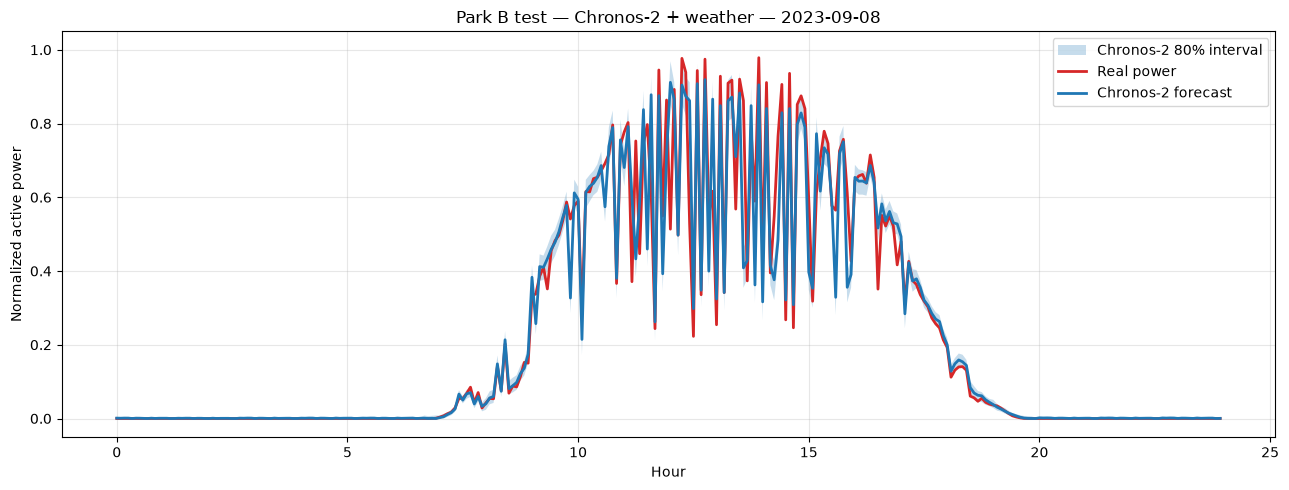

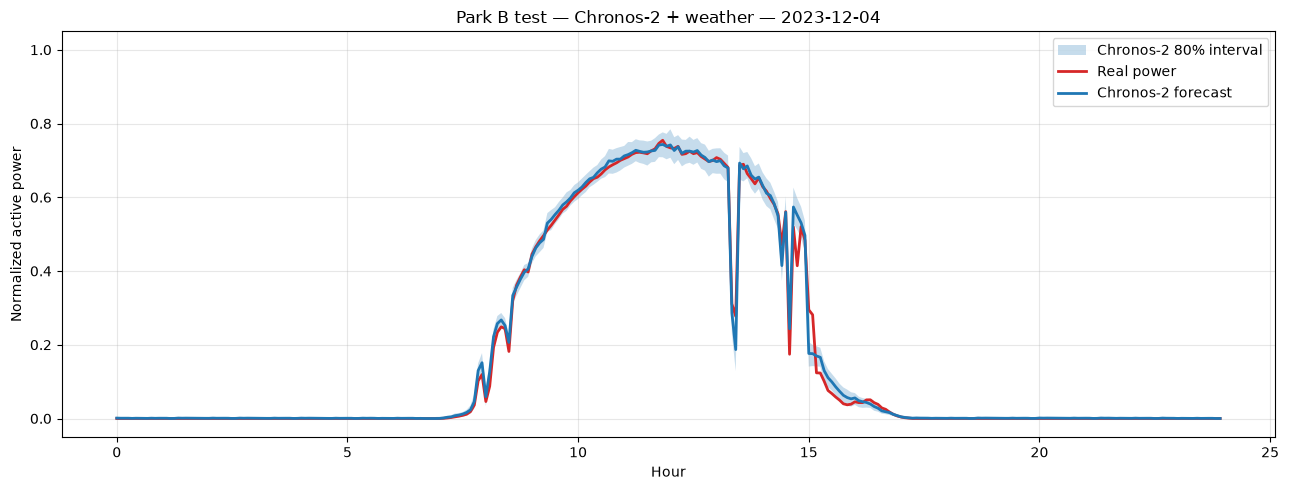

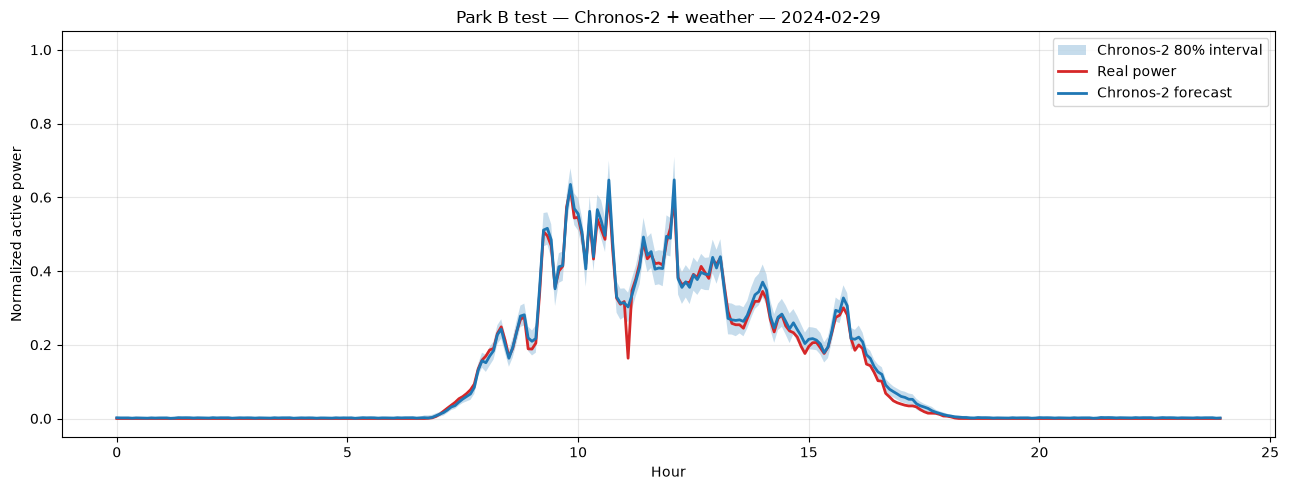

In [29]:
for day_index in sorted(set([0, len(park_b_targets) // 2, len(park_b_targets) - 1])):
    plot_forecast_day(
        day_index,
        park_b_dates,
        park_b_targets,
        park_b_forecast,
        park_b_quantiles,
        title=f"Park B test — {experiment_label}",
    )


## 9. Optional: save forecasts

The default run is the no-weather Chronos-2 baseline. Change the flag
near the top and rerun the forecasting and evaluation cells to obtain
the weather-covariate version.


In [30]:
output_name = (
    "Chronos2_weather_ParkB.npz"
    if USE_WEATHER_COVARIATES
    else "Chronos2_baseline_ParkB.npz"
)
output_path = base_dir / "data" / "Predictions" / output_name

# Uncomment to save the normalized point and quantile forecasts.
# output_path.parent.mkdir(parents=True, exist_ok=True)
# np.savez(
#     output_path,
#     point_forecast=park_b_forecast,
#     quantiles=park_b_quantiles,
#     targets=park_b_targets,
#     dates=park_b_dates,
#     quantile_levels=QUANTILE_LEVELS,
# )
# print("Saved:", output_path)

print("Point forecasts:", park_b_forecast.shape)
print("Quantile forecasts:", park_b_quantiles.shape)


Point forecasts: (175, 288)
Quantile forecasts: (175, 288, 9)


## How weather is used safely

With `USE_WEATHER_COVARIATES=True`, Chronos-2 receives:

- historical normalized active power for the seven-day context;
- weather and solar features over the same context;
- weather and solar features for the forecast day;
- **no active power from the forecast day**.

Chronos-2 handles these as covariates through `context_df` and
`future_df`. For a realistic operational experiment, replace the
forecast-day measured irradiance and temperature with values from a
weather forecast such as Open-Meteo. Measured future weather is useful
only as an oracle or upper-bound experiment.
